In [1]:
!pip install librosa numpy matplotlib fastdtw scipy


In [ ]:
import librosa
import numpy as np
import os

DATA_DIR = "Data/data_suara/Person1/Buka"   # sesuaikan folder kamu

def extract_mfcc(path, sr=16000, n_mfcc=20):
    y, sr = librosa.load(path, sr=sr)
    y = librosa.util.normalize(y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T

dataset_mfcc = []
files = []

for f in os.listdir(DATA_DIR):
    if f.lower().endswith(".wav"):
        full_path = os.path.join(DATA_DIR, f)
        mfcc = extract_mfcc(full_path)
        dataset_mfcc.append(mfcc)
        files.append(f)

print("Jumlah file WAV:", len(dataset_mfcc))
files


Jumlah file WAV: 50


['Buka_42.wav',
 'Buka_39.wav',
 'Buka_7.wav',
 'Buka_11.wav',
 'Buka_3.wav',
 'Buka_5.wav',
 'Buka_45.wav',
 'Buka_2.wav',
 'Buka_12.wav',
 'Buka_17.wav',
 'Buka_13.wav',
 'Buka_29.wav',
 'Buka_20.wav',
 'Buka_14.wav',
 'Buka_24.wav',
 'Buka_10.wav',
 'Buka_31.wav',
 'Buka_41.wav',
 'Buka_49.wav',
 'Buka_9.wav',
 'Buka_30.wav',
 'Buka_40.wav',
 'Buka_32.wav',
 'Buka_46.wav',
 'Buka_36.wav',
 'Buka_6.wav',
 'Buka_43.wav',
 'Buka_15.wav',
 'Buka_19.wav',
 'Buka_8.wav',
 'Buka_37.wav',
 'Buka_21.wav',
 'Buka_1.wav',
 'Buka_44.wav',
 'Buka_23.wav',
 'Buka_38.wav',
 'Buka_28.wav',
 'Buka_47.wav',
 'Buka_22.wav',
 'Buka_4.wav',
 'Buka_26.wav',
 'Buka_50.wav',
 'Buka_27.wav',
 'Buka_48.wav',
 'Buka_35.wav',
 'Buka_25.wav',
 'Buka_33.wav',
 'Buka_34.wav',
 'Buka_16.wav',
 'Buka_18.wav']

Jumlah file ditemukan: 50


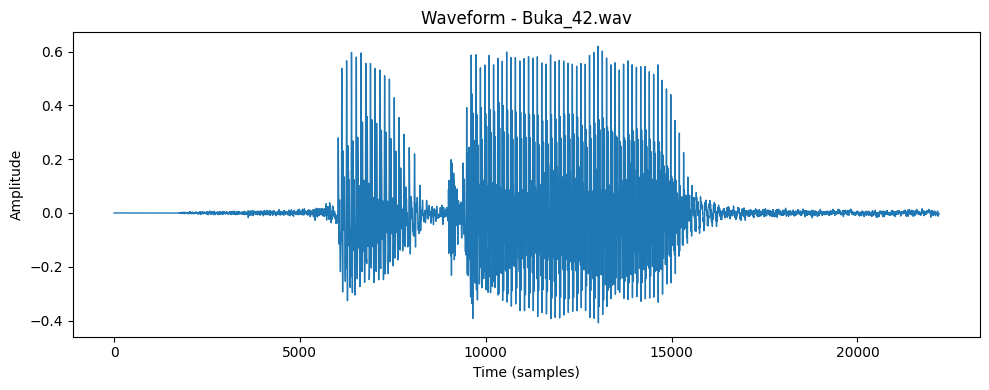

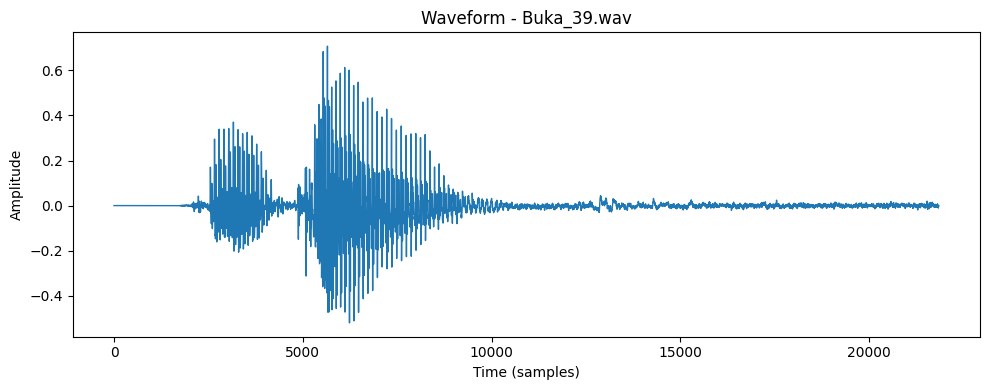

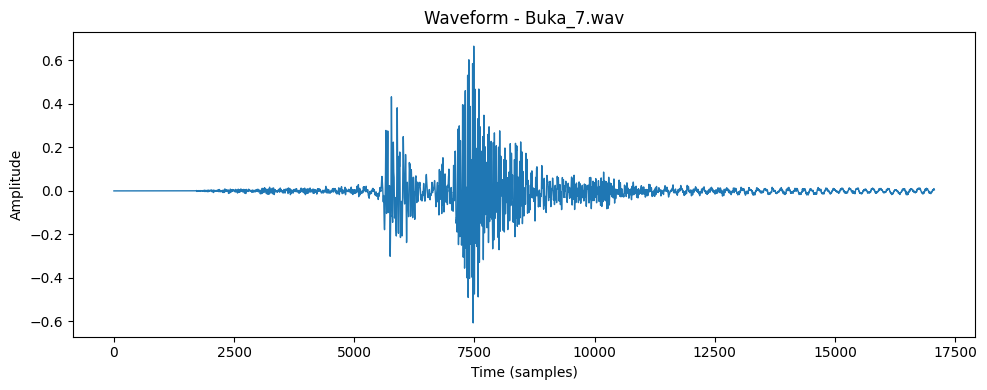

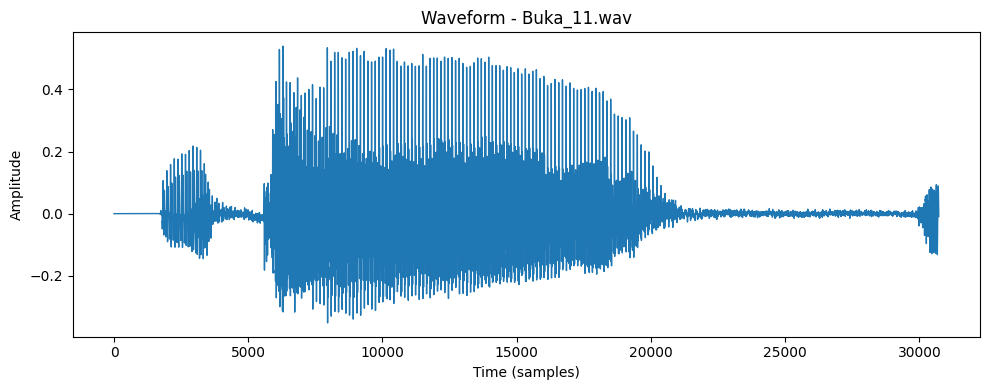

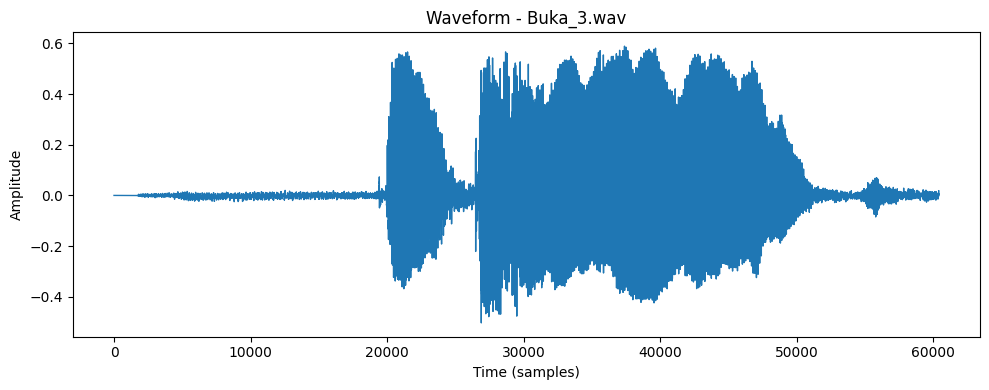

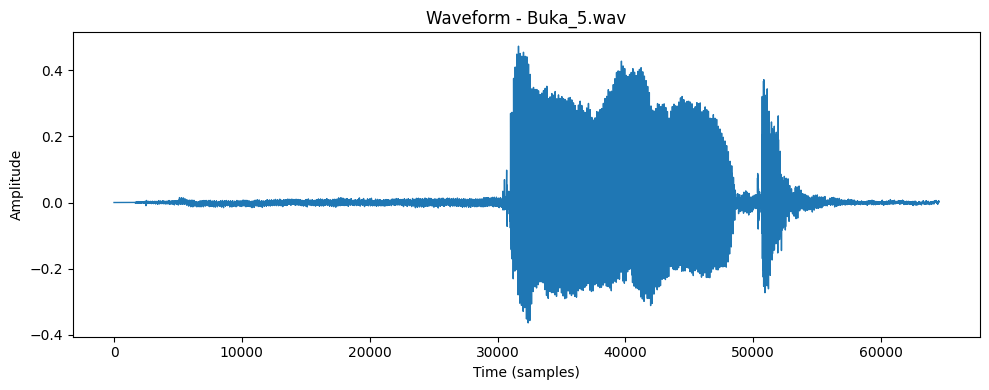

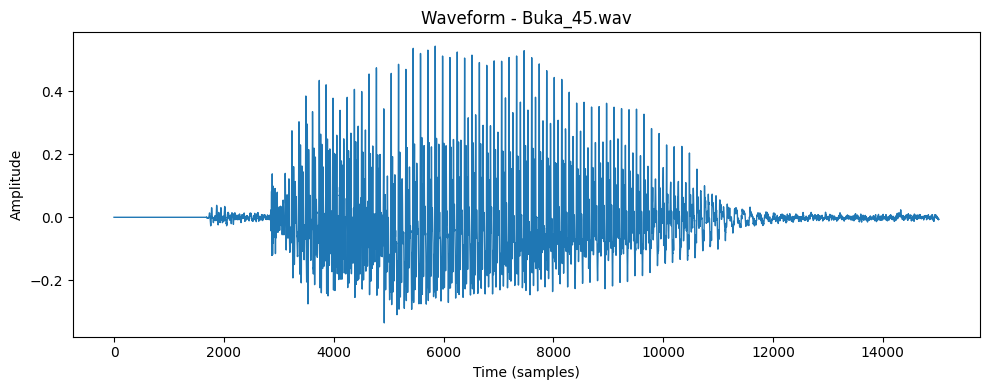

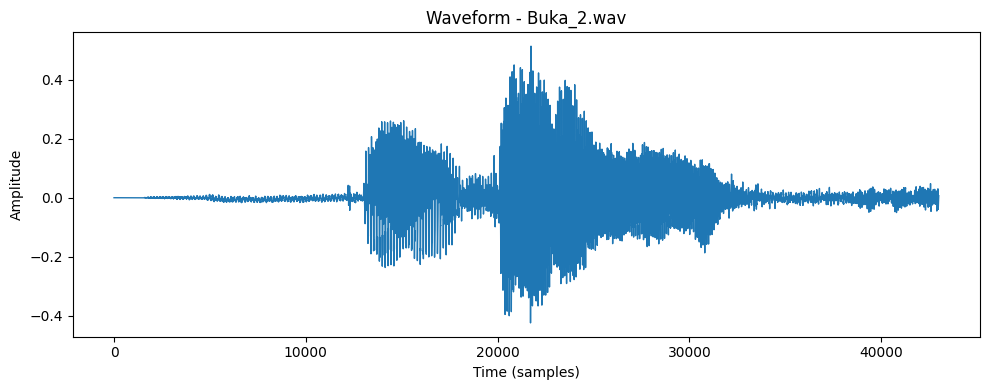

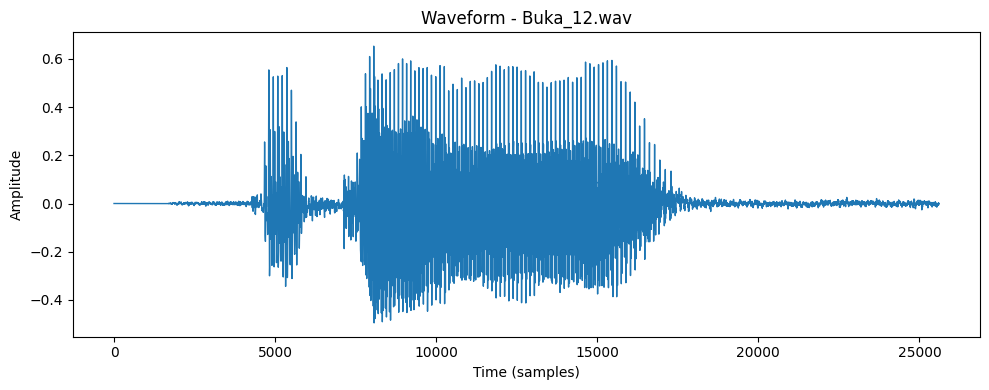

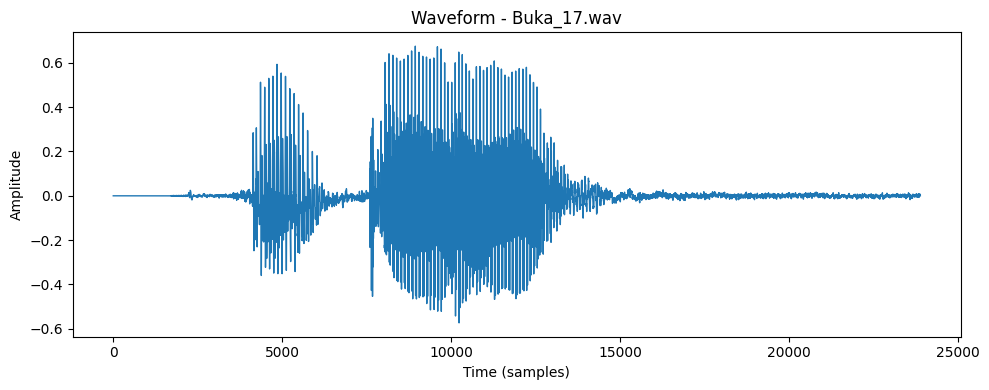

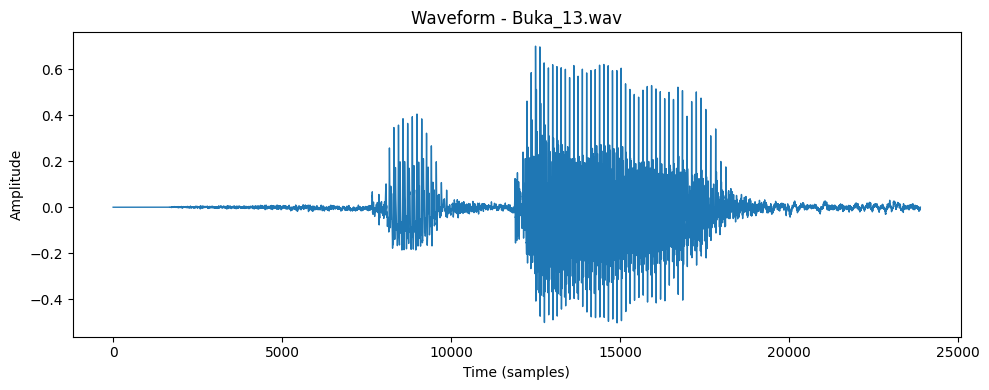

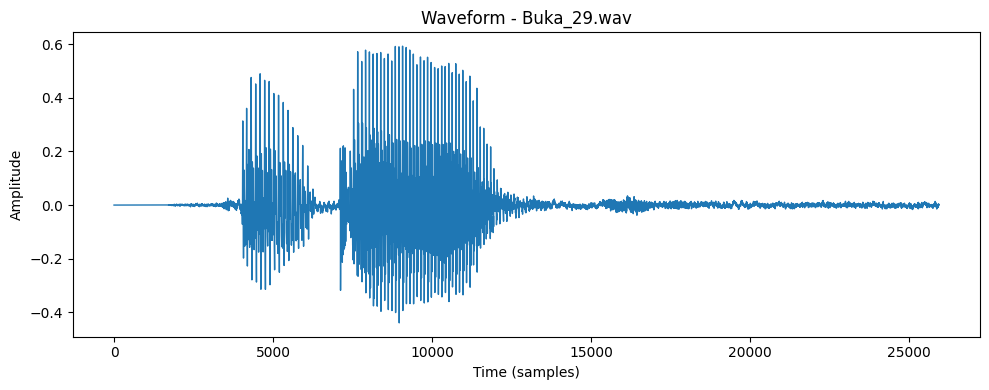

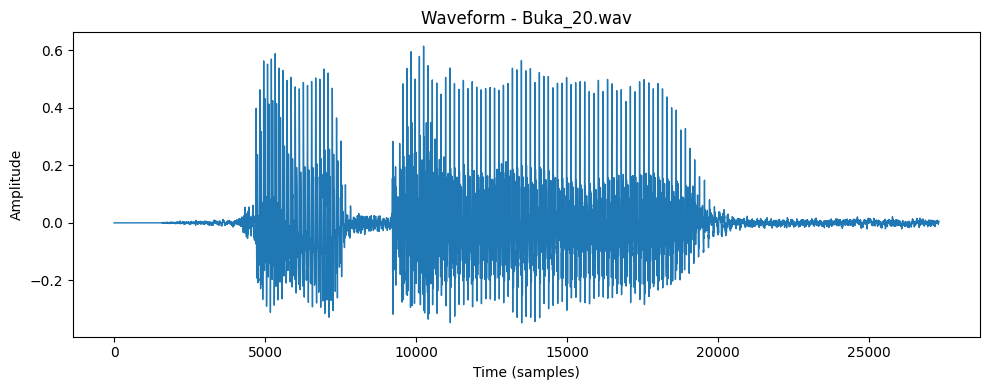

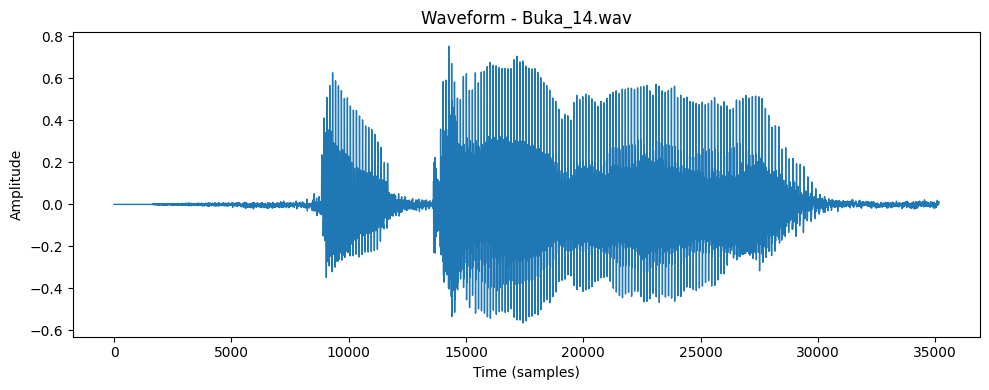

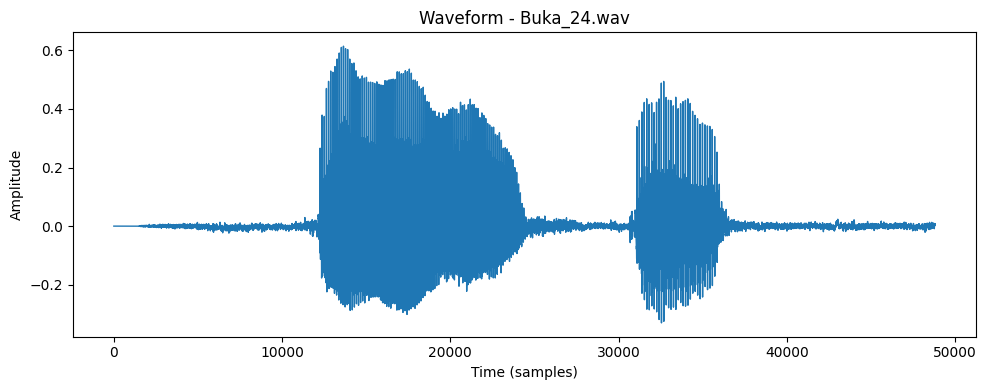

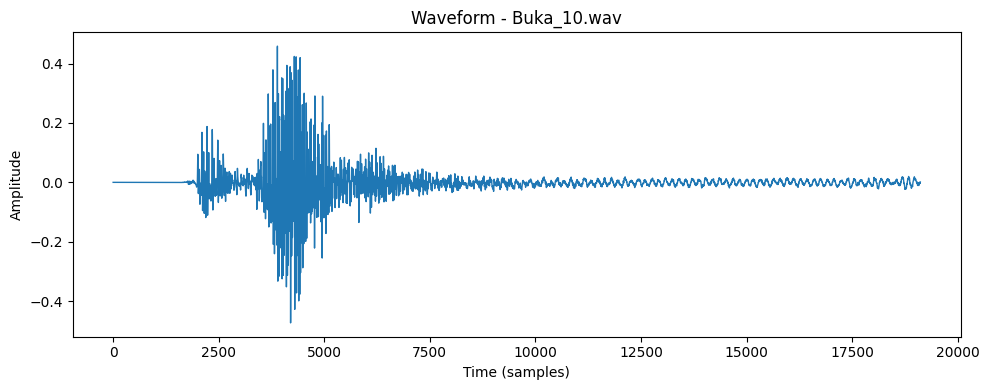

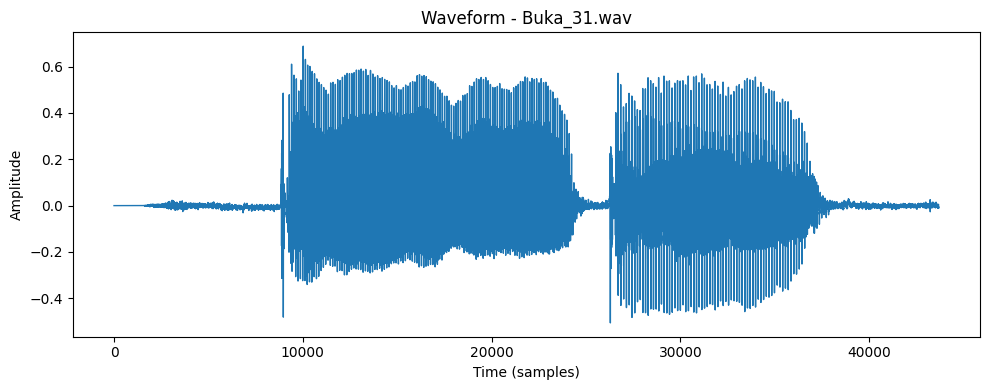

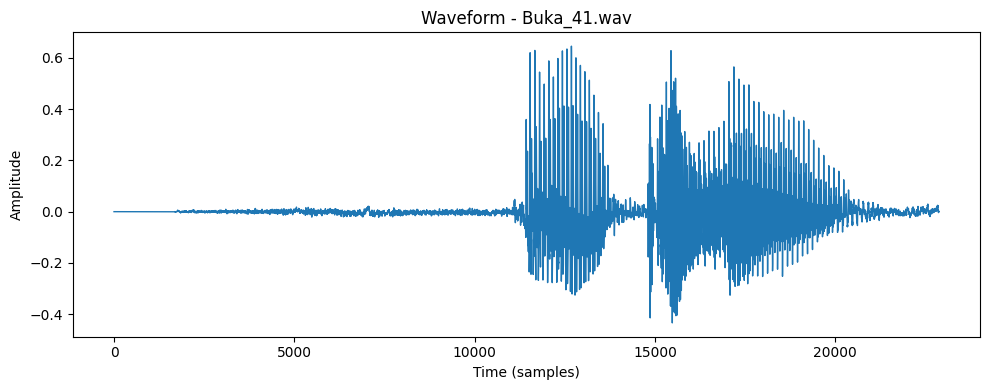

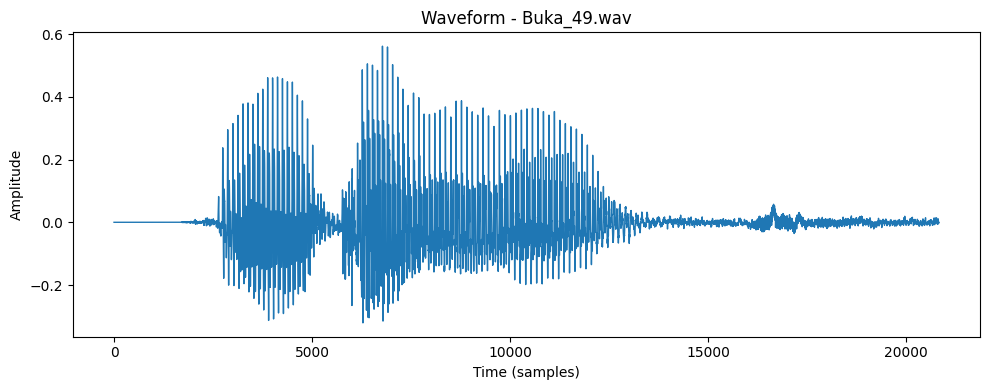

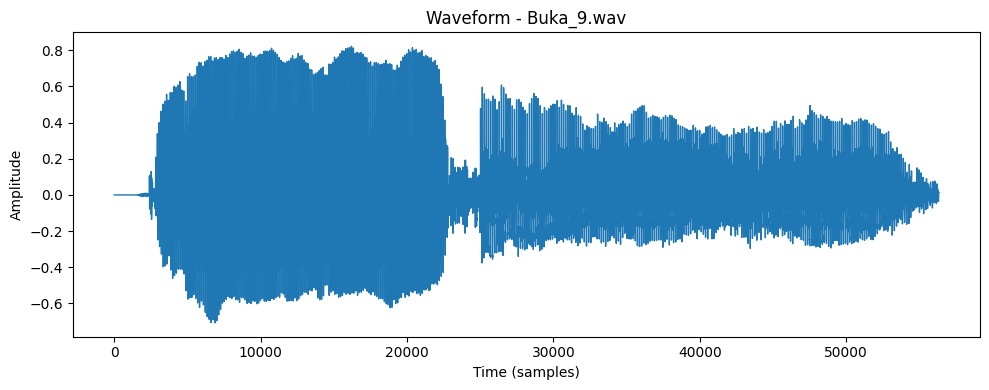

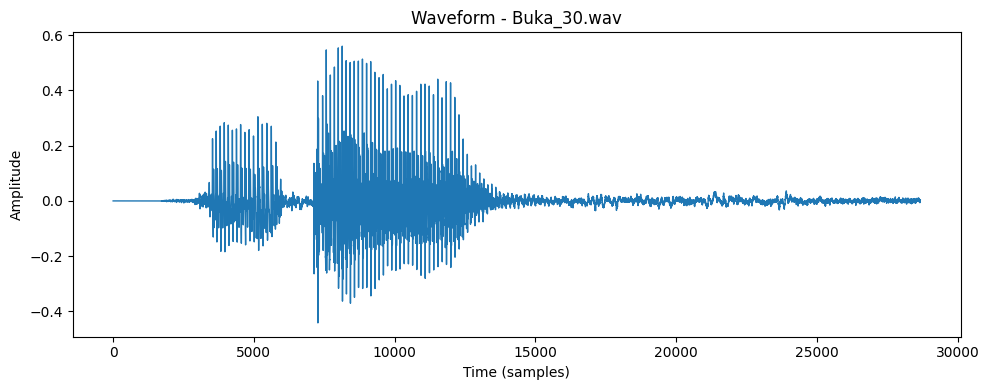

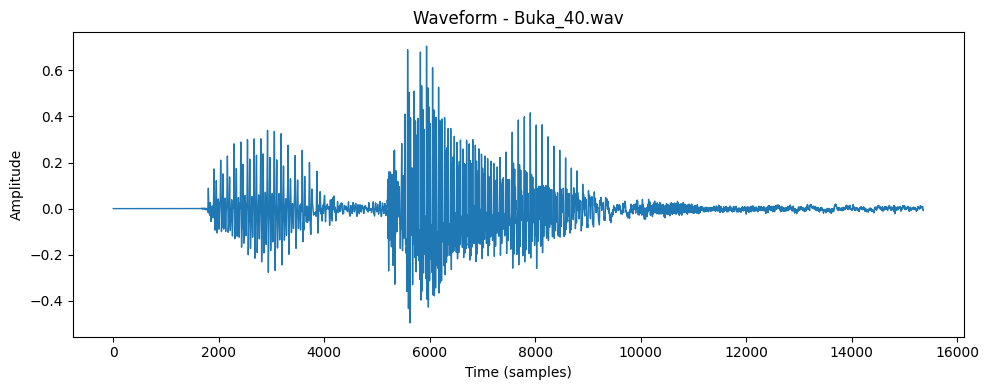

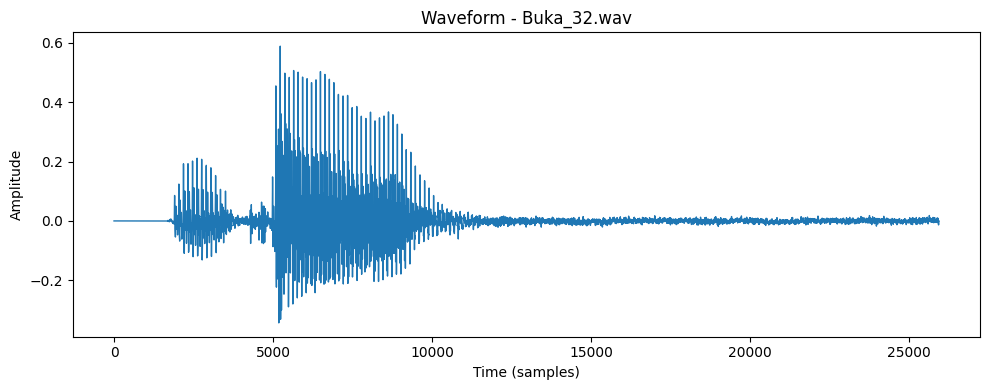

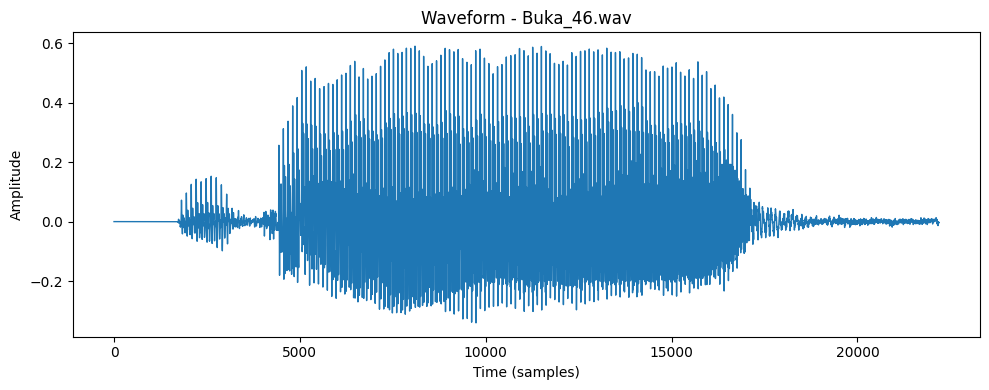

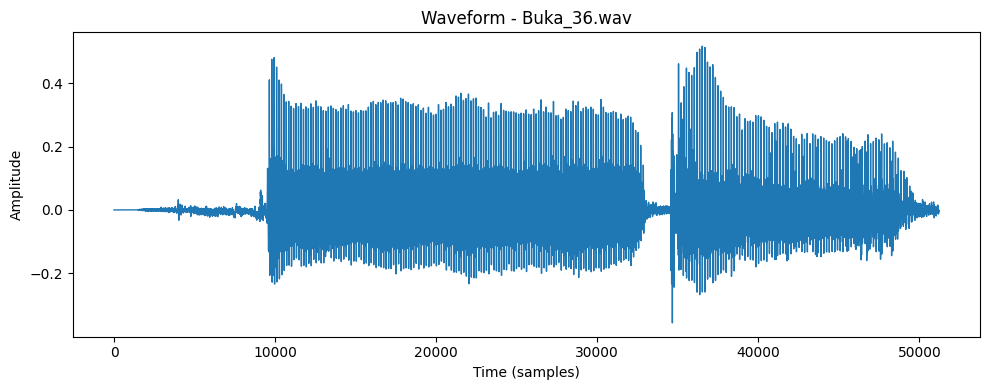

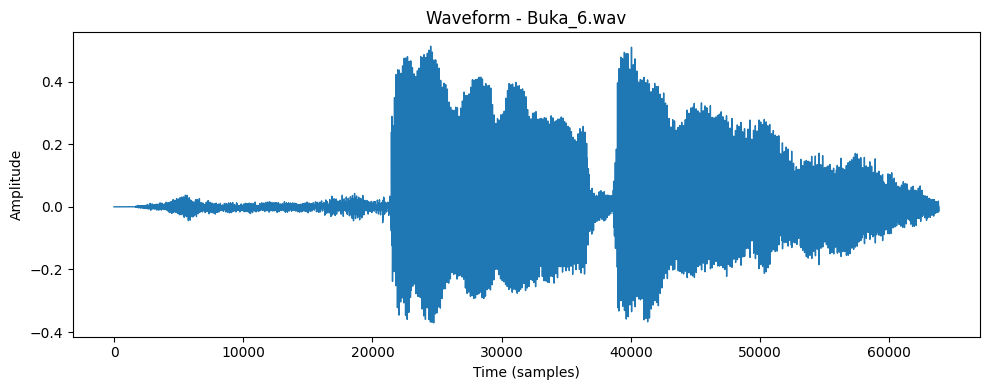

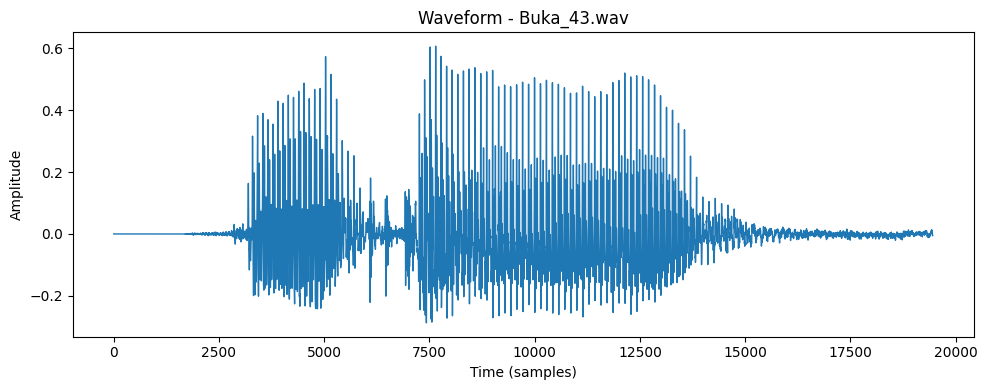

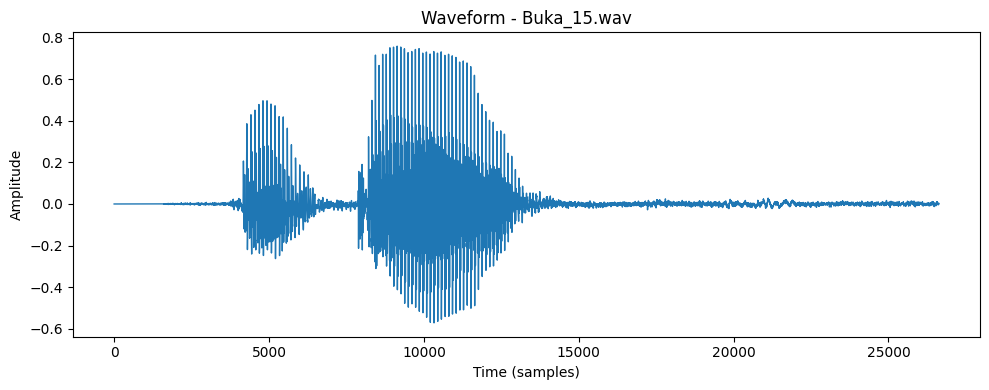

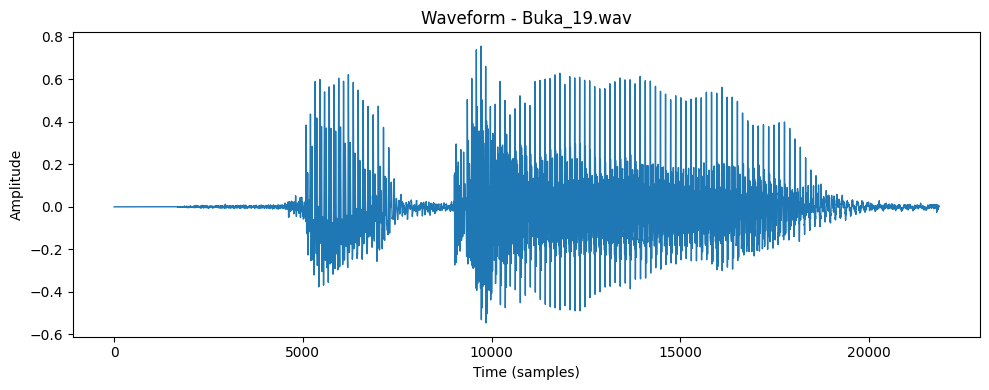

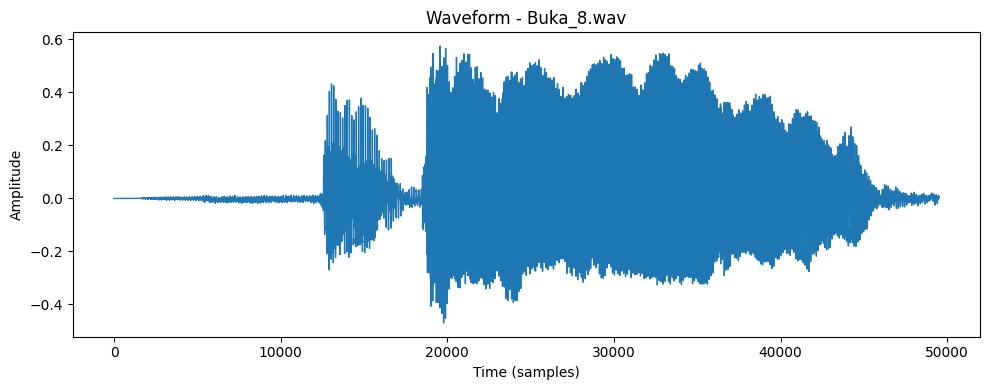

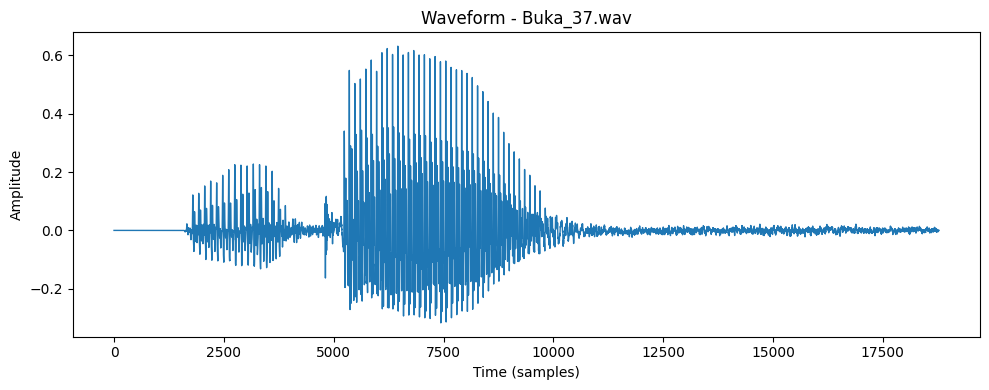

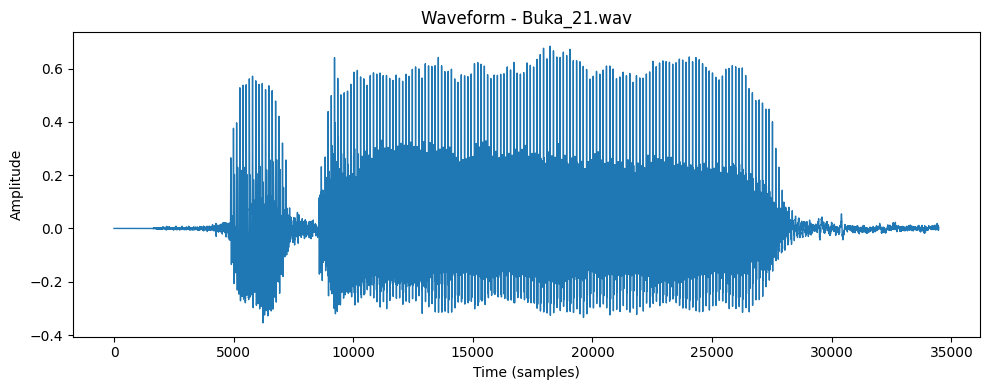

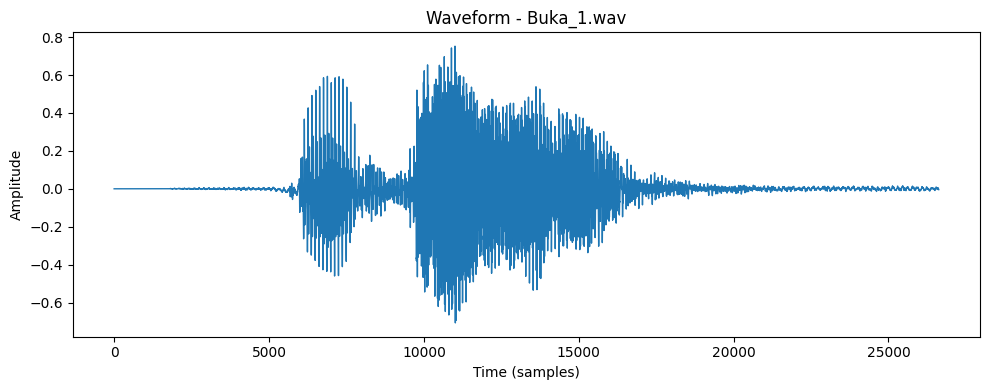

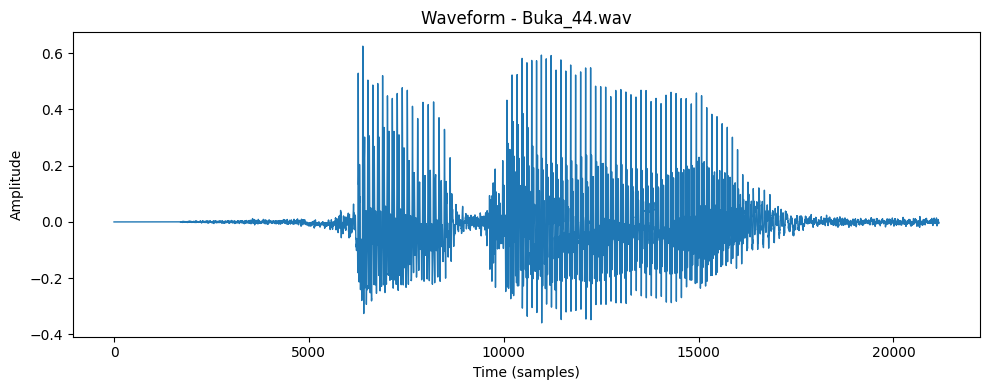

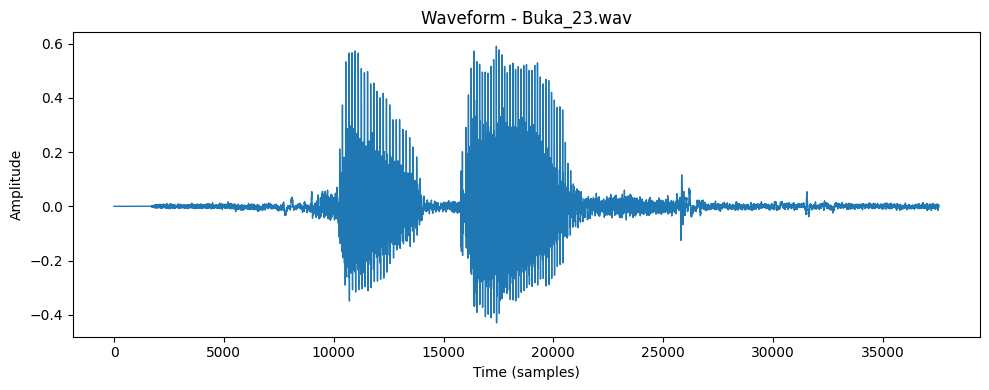

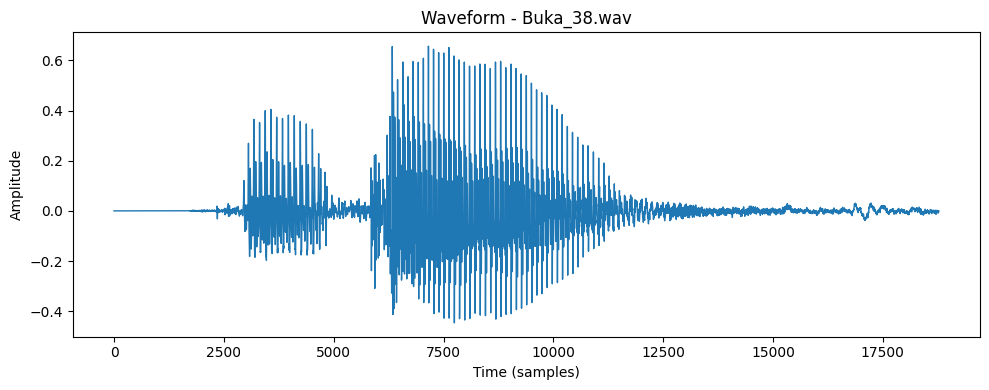

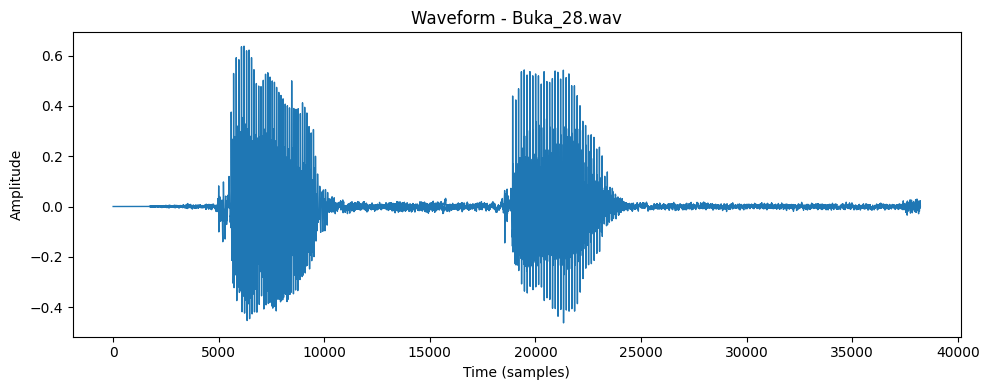

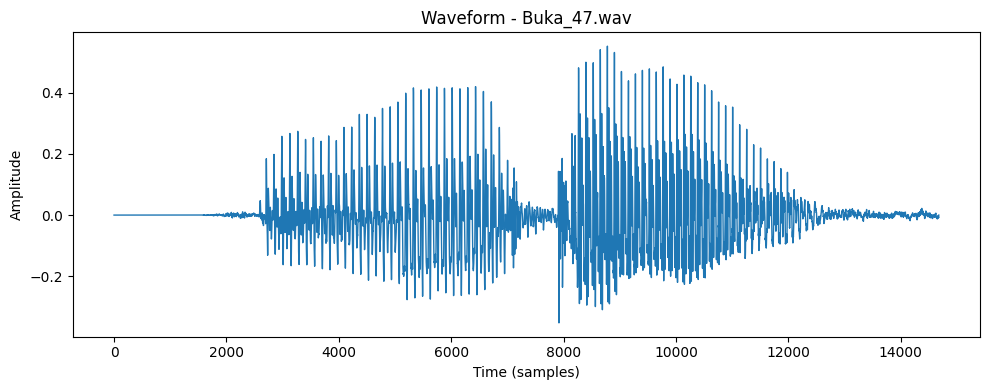

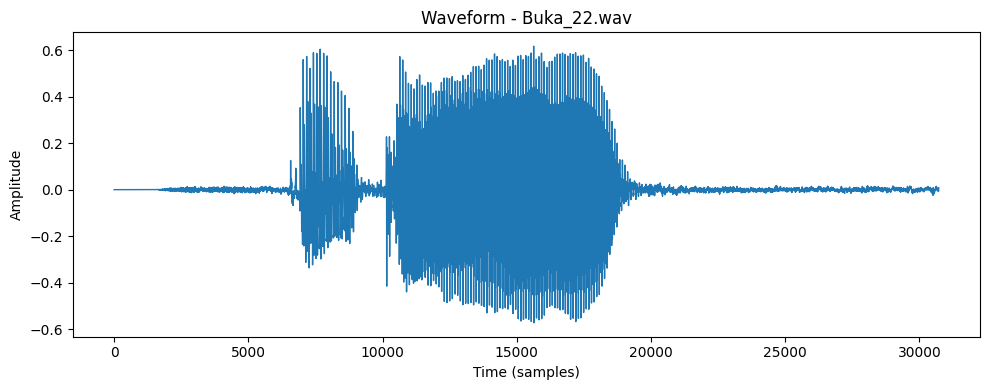

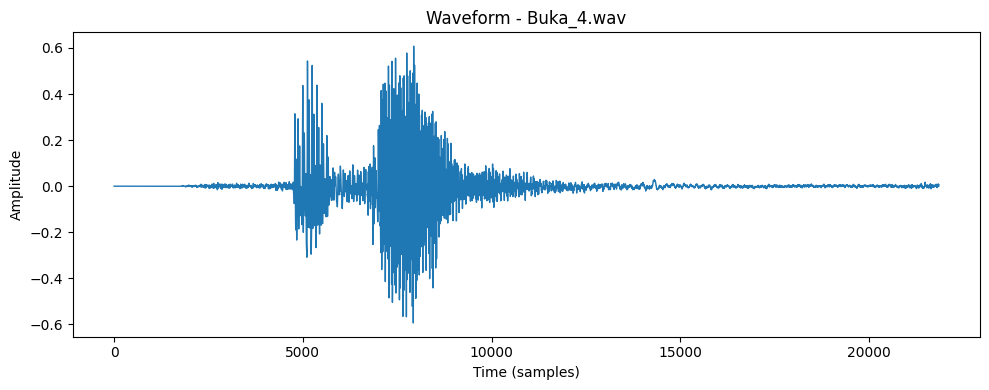

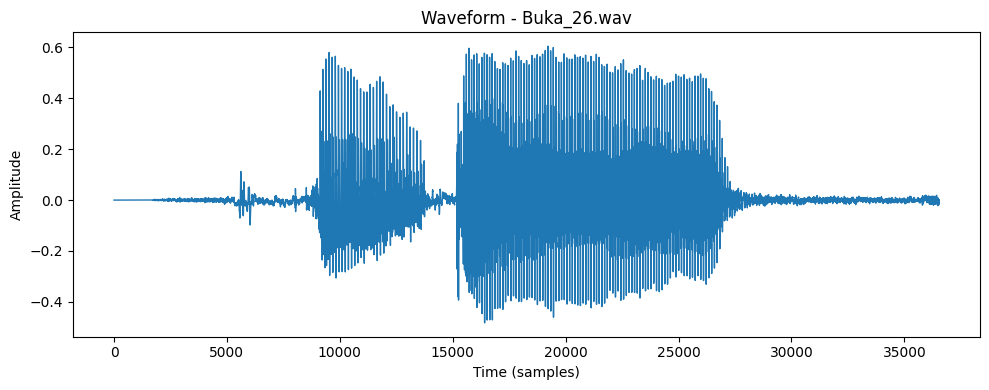

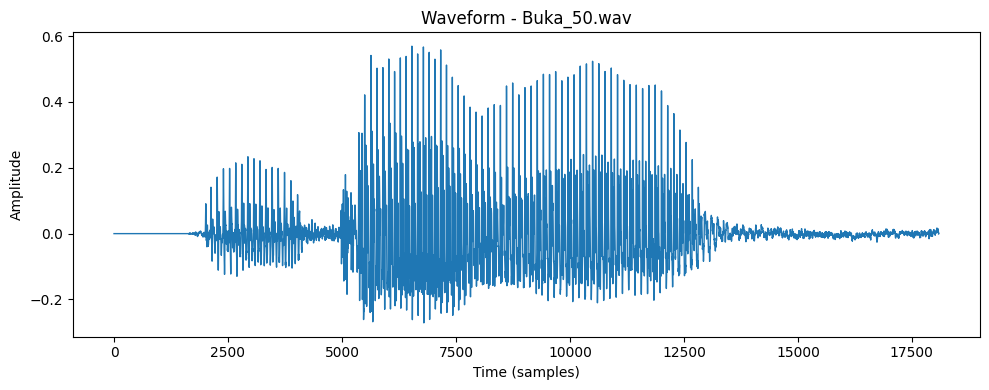

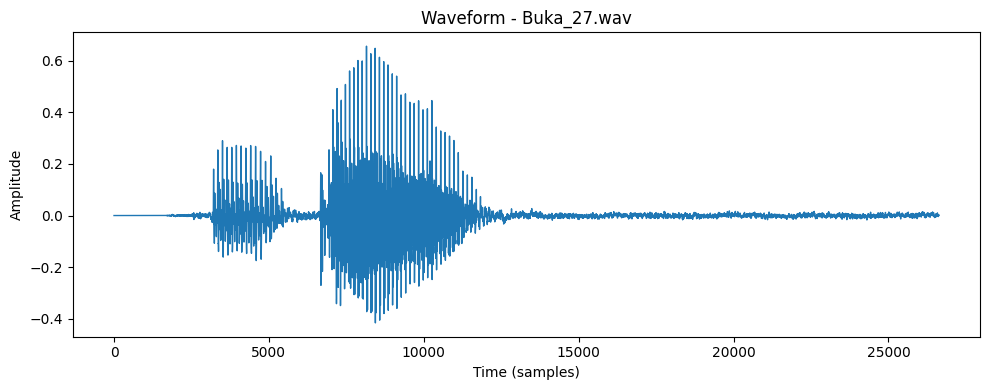

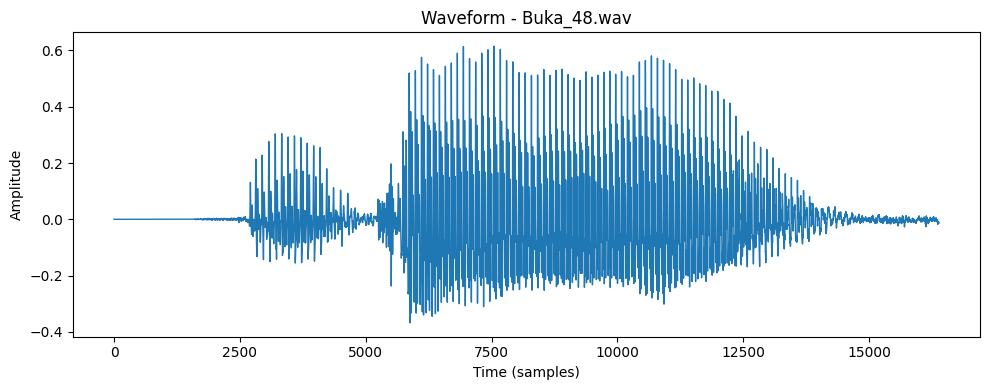

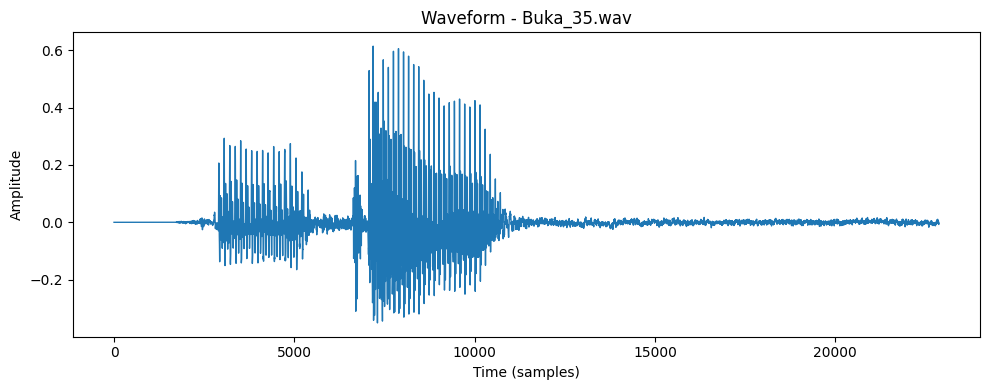

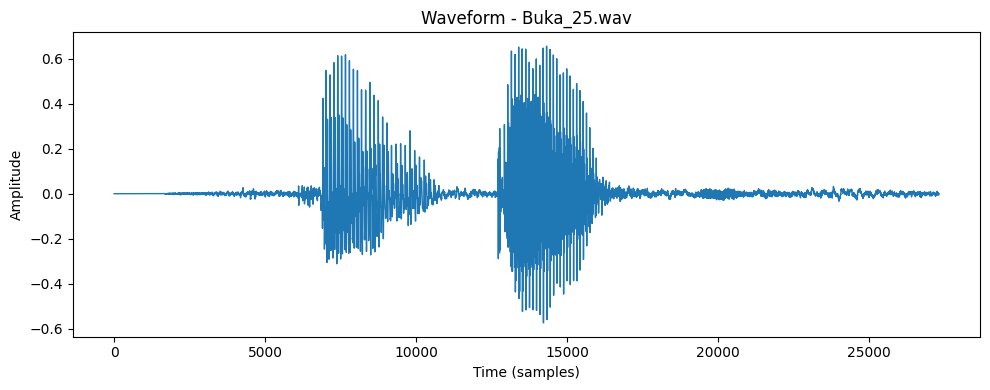

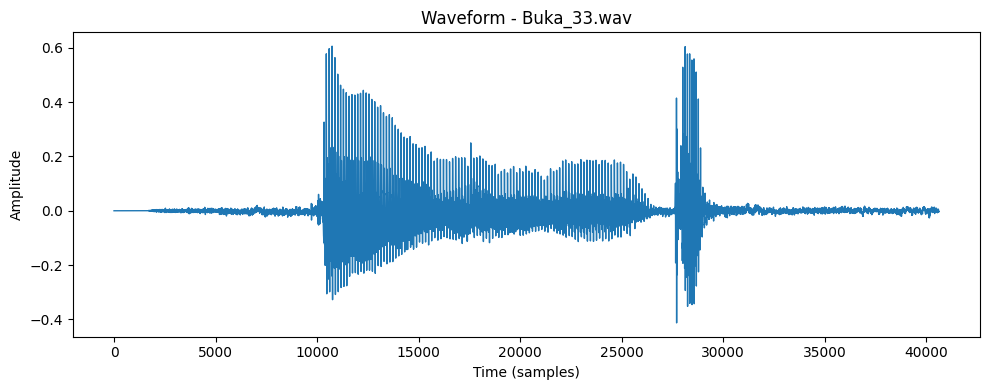

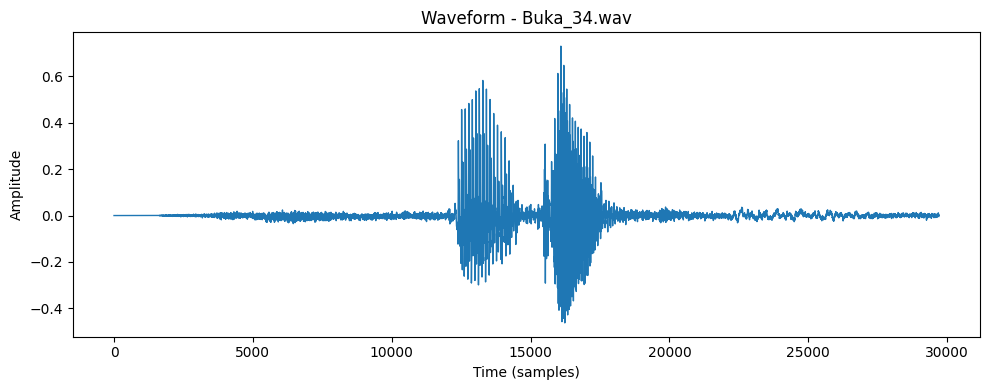

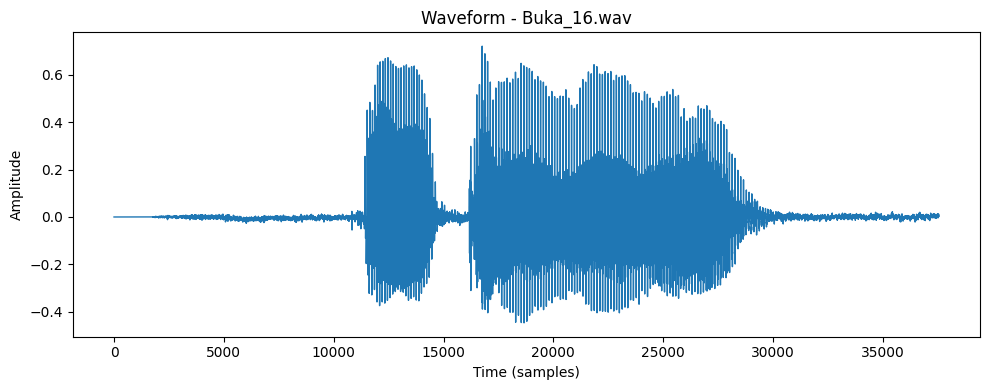

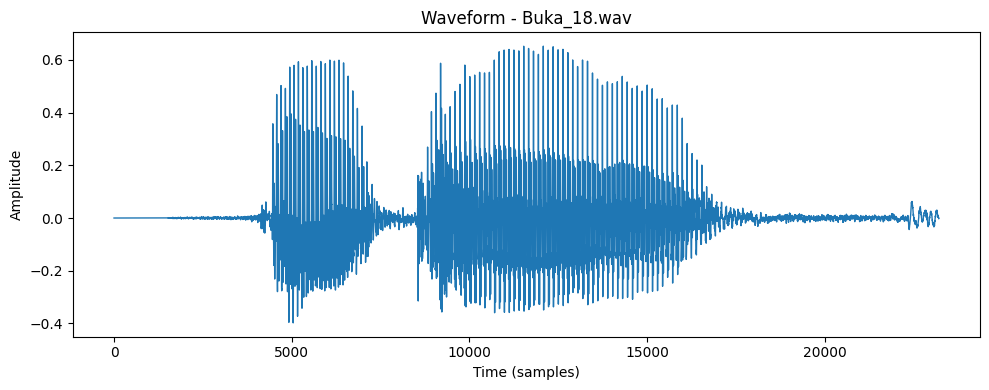

In [6]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

DATA_DIR = "Data/data_suara/Person1/Buka"   # ganti dengan folder berisi 50 file buka .wav

wav_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".wav")]

print("Jumlah file ditemukan:", len(wav_files))

for filename in wav_files:
    full_path = os.path.join(DATA_DIR, filename)

    # Load audio
    y, sr = librosa.load(full_path, sr=16000)

    # Plot waveform 1 garis
    plt.figure(figsize=(10,4))
    plt.plot(y, linewidth=1)
    plt.title(f"Waveform - {filename}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


In [1]:
!pip install fastdtw
!pip install pydub
!pip install ffmpeg-python
!sudo apt-get update
!sudo apt-get install ffmpeg
!pip install torch torchaudio


Hit:1 https://dl.yarnpkg.com/debian stable InRelease
Hit:2 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease
Hit:3 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease       
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease     
Hit:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease                 
Hit:6 http://security.ubuntu.com/ubuntu noble-security InRelease               
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease               
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:6.1.1-3ubuntu5).
0 upgraded, 0 newly installed, 0 to remove and 109 not upgraded.


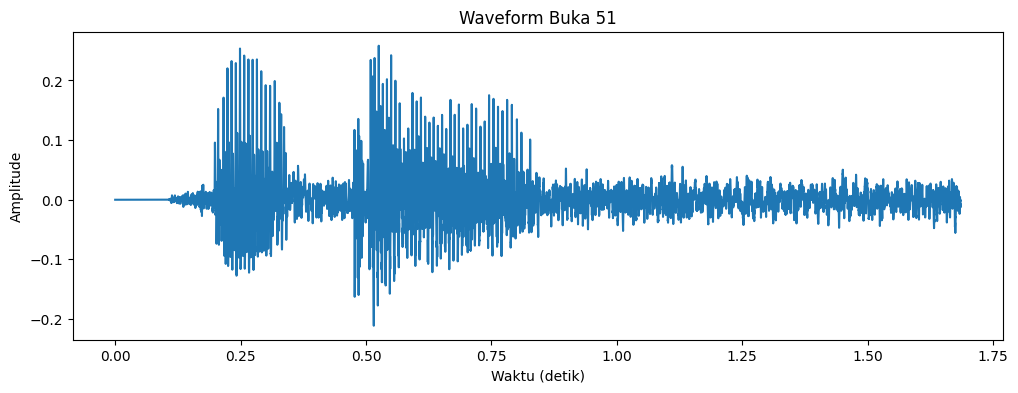

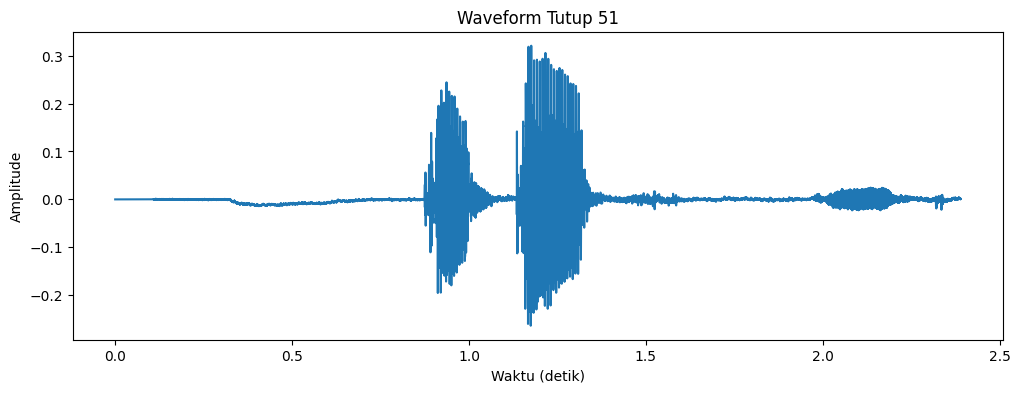

Total buka = 50
Total tutup = 50
Data/data_suara/Person1/Buka/Buka_1.wav → DTW = 11017.87
Data/data_suara/Person1/Buka/Buka_10.wav → DTW = 8165.74
Data/data_suara/Person1/Buka/Buka_11.wav → DTW = 12299.42
Data/data_suara/Person1/Buka/Buka_12.wav → DTW = 9619.23
Data/data_suara/Person1/Buka/Buka_13.wav → DTW = 8674.58
Data/data_suara/Person1/Buka/Buka_14.wav → DTW = 12700.42
Data/data_suara/Person1/Buka/Buka_15.wav → DTW = 8374.09
Data/data_suara/Person1/Buka/Buka_16.wav → DTW = 13386.12
Data/data_suara/Person1/Buka/Buka_17.wav → DTW = 9069.47
Data/data_suara/Person1/Buka/Buka_18.wav → DTW = 8492.26
Data/data_suara/Person1/Buka/Buka_19.wav → DTW = 9500.88
Data/data_suara/Person1/Buka/Buka_2.wav → DTW = 10882.96
Data/data_suara/Person1/Buka/Buka_20.wav → DTW = 9823.92
Data/data_suara/Person1/Buka/Buka_21.wav → DTW = 13549.97
Data/data_suara/Person1/Buka/Buka_22.wav → DTW = 12030.58
Data/data_suara/Person1/Buka/Buka_23.wav → DTW = 13036.01
Data/data_suara/Person1/Buka/Buka_24.wav → DTW = 

In [2]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from fastdtw import fastdtw
import torchaudio
import torch
import glob

# --------------------------------------------------------
# MFCC menggunakan TORCHAUDIO (NO SCIPY, NO LIBROSA)
# --------------------------------------------------------
mfcc_extractor = torchaudio.transforms.MFCC(
    sample_rate=16000,
    n_mfcc=20,
    melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
)

def ekstrak_fitur_mfcc(path):
    audio, sr = sf.read(path)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # Resample jika bukan 16k
    if sr != 16000:
        audio = torchaudio.functional.resample(
            torch.tensor(audio, dtype=torch.float32), sr, 16000
        )
        sr = 16000
    else:
        audio = torch.tensor(audio, dtype=torch.float32)

    # MFCC (output shape: [1, 20, time])
    mfcc = mfcc_extractor(audio).squeeze().numpy()

    return audio.numpy(), sr, mfcc


# --------------------------------------------------------
# Euclidean distance
# --------------------------------------------------------
def euclidean(a, b):
    return np.linalg.norm(a - b)


# --------------------------------------------------------
# DTW
# --------------------------------------------------------
def hitung_dtw(mfcc1, mfcc2):
    dist, _ = fastdtw(mfcc1.T, mfcc2.T, dist=euclidean)
    return dist


# --------------------------------------------------------
# Grafik waveform
# --------------------------------------------------------
def tampilkan_grafik(audio, sr, judul):
    plt.figure(figsize=(12, 4))
    plt.plot(np.linspace(0, len(audio)/sr, len(audio)), audio)
    plt.title(judul)
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitude")
    plt.show()


# =======================================================
# LOAD SUARA BARU (WAV)
# =======================================================
buka_path = "Data/data_uji_suara/Buka_51.wav"
tutup_path = "Data/data_uji_suara/Tutup_51.wav"

audio_buka, sr_buka, mfcc_buka = ekstrak_fitur_mfcc(buka_path)
audio_tutup, sr_tutup, mfcc_tutup = ekstrak_fitur_mfcc(tutup_path)

tampilkan_grafik(audio_buka, sr_buka, "Waveform Buka 51")
tampilkan_grafik(audio_tutup, sr_tutup, "Waveform Tutup 51")


# =======================================================
# LOAD DATASET LATIH
# =======================================================
folder_buka = sorted(glob.glob("Data/data_suara/Person1/Buka/*.wav"))
folder_tutup = sorted(glob.glob("Data/data_suara/Person1/Tutup/*.wav"))

print("Total buka =", len(folder_buka))
print("Total tutup =", len(folder_tutup))


# =======================================================
# HITUNG DTW
# =======================================================
def hitung_dtw_ke_semua(folder_files, mfcc_baru):
    hasil = []
    for file in folder_files:
        _, _, mfcc_lama = ekstrak_fitur_mfcc(file)
        skor = hitung_dtw(mfcc_lama, mfcc_baru)
        hasil.append((file, skor))
        print(f"{file} → DTW = {skor:.2f}")
    return hasil

hasil_buka = hitung_dtw_ke_semua(folder_buka, mfcc_buka)
hasil_tutup = hitung_dtw_ke_semua(folder_tutup, mfcc_tutup)

hasil_buka_sorted = sorted(hasil_buka, key=lambda x: x[1])
hasil_tutup_sorted = sorted(hasil_tutup, key=lambda x: x[1])


# =======================================================
# OUTPUT
# =======================================================
print("\n=== TOP 10 BUKA ===")
for f, s in hasil_buka_sorted[:10]:
    print(f"{f} → {s:.2f}")

print("\n=== TOP 10 TUTUP ===")
for f, s in hasil_tutup_sorted[:10]:
    print(f"{f} → {s:.2f}")
